In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
# from ibllib.atlas import AllenAtlas
# from brainbox.io.spikeglx import Streamer
# from neurodsp.voltage import destripe
# from datetime import datetime
# from pprint import pprint

# ba = AllenAtlas()
# br = ba.regions
# ba.compute_regions_volume()


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-fbb775ba-fefd-2eb2-59fe-085205063300)


In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [5]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    # 'epochs':50,
    # 'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [6]:
# @title Load data
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)

brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
acronym_selec_list = list_dict['acronym_selec_list']

In [ ]:
list_dict.keys()

In [ ]:
device.type

In [7]:
acu_test_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/acronym_test_dict.pt', weights_only=False)
subject_num = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/subject_stat.pt', weights_only=False)

In [8]:
from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:02<00:00, 10.96it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  2.57it/s]


In [9]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]

In [10]:
Cosmos_mark_index = []
Cosmos_mark_acronym = []
acronym_Cosmos0 = ''
for acronym_Cosmos_ii, acronym_Cosmos in enumerate(acronym_list_Cosmos):
    if acronym_Cosmos != acronym_Cosmos0:
        Cosmos_mark_index.append(acronym_Cosmos_ii)
        Cosmos_mark_acronym.append(acronym_Cosmos)
        acronym_Cosmos0 = acronym_Cosmos


In [11]:
select_acronym_list = [
    'FRP2/3',
    'FRP5',
    'VISp2/3',
    'VISp5',
    'DG-mo',
    'DG-po',
    'DG-sg',
    'CA1',
    'CA2',
    'CA3',
]


In [12]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
acronym_id_marked = []
acu_id_marked = []
acronym_marked = []
for acronym_ii, acronym in enumerate(acronym_list):
    acu_test_dict_selec = acu_test_dict[acu_test_dict['acronym_test'] == acronym]
    if len(acu_test_dict_selec) < 1:
        continue
    mean_max = 0
    for name0 in Classifier_name:
        # print(acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'])
        mean0 = acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'].mean()
        # print(mean0)
        if mean0 > mean_max:
            mean_max = mean0
    if (mean_max > 0.75) or (acronym in select_acronym_list):
        print(acronym_ii)
        print(acronym)
        acronym_id_marked.append(acronym_ii)
        acu_id_marked.append(mean_max)
        acronym_marked.append(acronym)

1
FRP2/3
2
FRP5
14
SSp-n1
85
VISal6a
100
VISp2/3
102
VISp5
106
VISpl2/3
209
DG-mo
210
DG-po
211
DG-sg
214
ENTl1
232
BLAv
327
PBG
421
MOB
431
CA1
432
CA2
433
CA3


In [13]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [14]:
acronym_stat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/acronym_stat.pt', weights_only=False)
subject_n = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/subject_n.pt', weights_only=False)

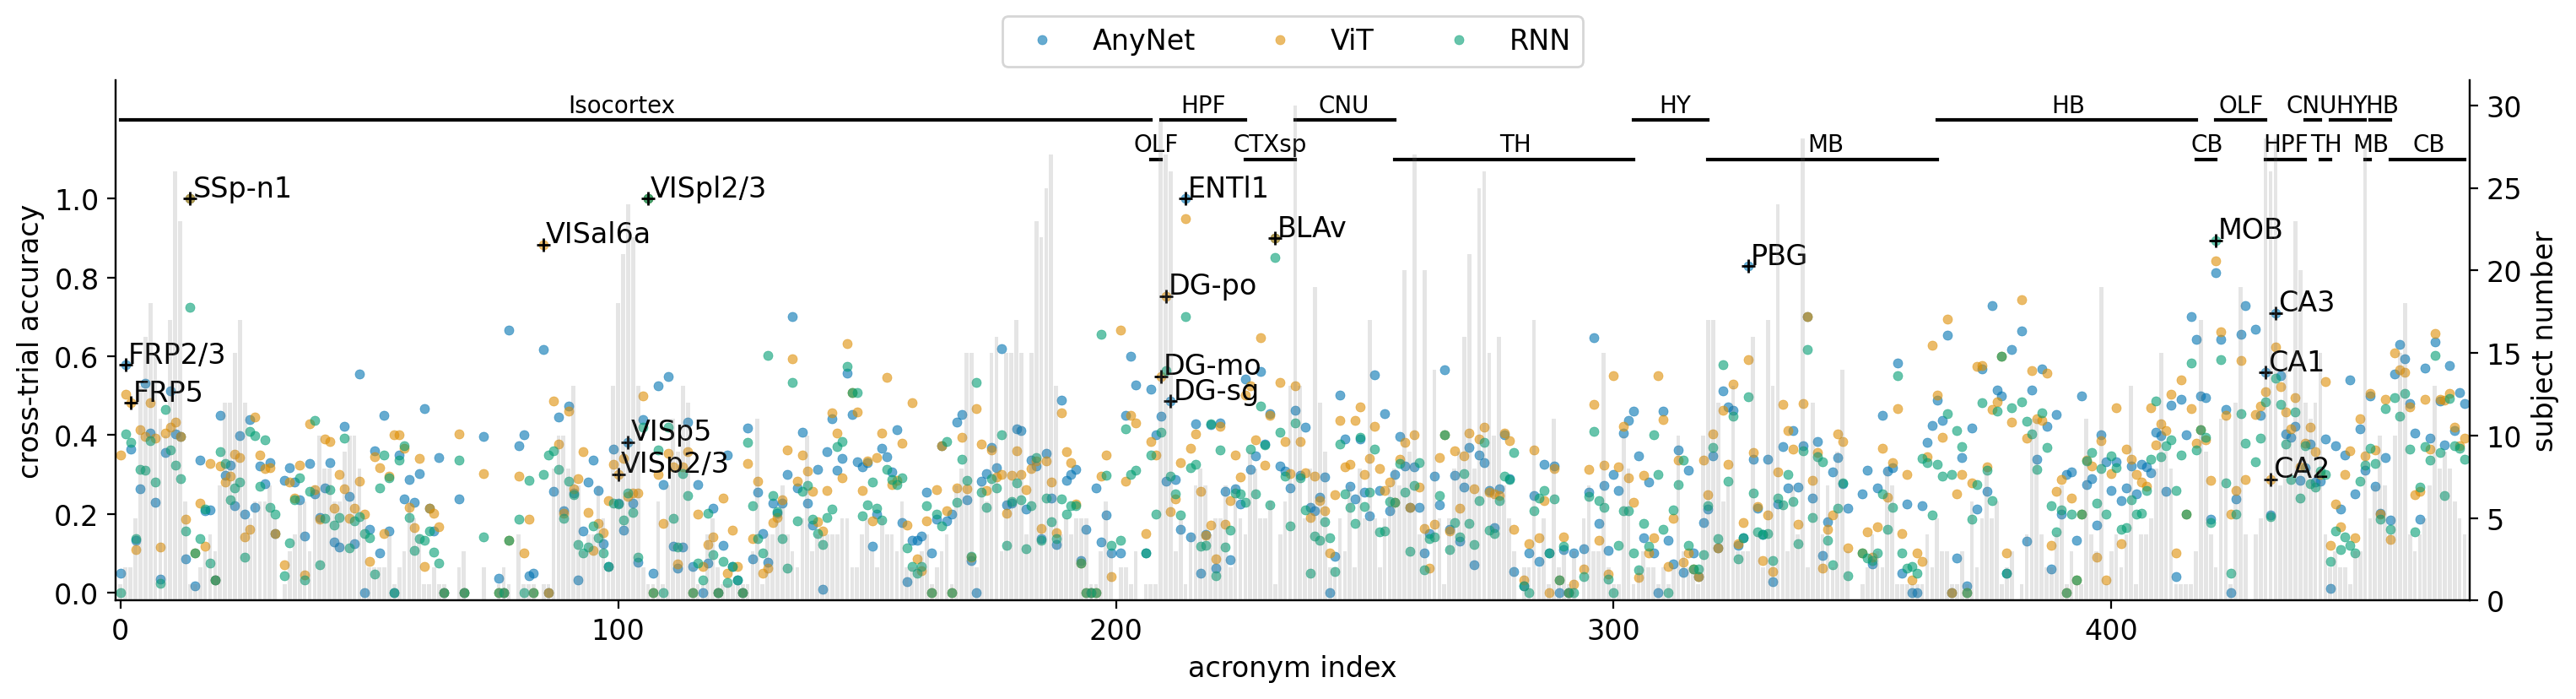

In [15]:
# sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid', font_scale=1.0)
plt.figure(figsize=(18, 4), dpi=200)

# g = sns.FacetGrid(data=acu_test, row='model_type')
g = sns.pointplot(data=acu_test_dict, x='acronym_index_test', y='acu_test', hue='name',linestyles='none', palette='colorblind', errorbar=None, linewidth=0.3, markersize=4, alpha=0.6)
plt.xticks([0, 100, 200, 300, 400], ['0', '100', '200', '300', '400'])
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
g.set_ylabel('cross-trial accuracy', fontsize=12)
g.set_xlabel('acronym index', fontsize=12)
for ii in range(0, len(acronym_id_marked)):
    g.text(acronym_id_marked[ii] + 0.5, acu_id_marked[ii] + 0.005, acronym_marked[ii], fontdict={'fontsize': 12})
    plt.plot(acronym_id_marked[ii], acu_id_marked[ii], 'k+')

for ii in range(0, len(Cosmos_mark_index) - 1):
    if ii % 2 == 0:
        plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii + 1]], [1.2, 1.2], '-', linewidth=1.5, color='black')
        # plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii]], [-0.1, 0], '-', color='gray')
        if Cosmos_mark_acronym[ii] == 'CNU':
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.8, 1.22, Cosmos_mark_acronym[ii])
        elif Cosmos_mark_acronym[ii] == 'HY':
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.2, 1.22, Cosmos_mark_acronym[ii])
        else:
            plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.22, Cosmos_mark_acronym[ii])
    else:
        plt.plot([Cosmos_mark_index[ii], Cosmos_mark_index[ii + 1]], [1.1, 1.1], '-', linewidth=1.5, color='black')
        plt.text((Cosmos_mark_index[ii] + Cosmos_mark_index[ii + 1])/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.12, Cosmos_mark_acronym[ii])

ii = ii + 1
plt.plot([Cosmos_mark_index[-1], len(acronym_list_Cosmos) - 1], [1.1, 1.1], '-', linewidth=1.5, color='black')
plt.text((Cosmos_mark_index[-1] + len(acronym_list_Cosmos) - 1)/2 - len(Cosmos_mark_acronym[ii])*1.5, 1.12, Cosmos_mark_acronym[ii])

g.set(xlim=([-1, len(acronym_list)]))
g.set(ylim=([-0.02, 1.3]))
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=12)
plt.xticks(['0', '100', '200', '300', '400'], [0, 100, 200, 300, 400], fontsize=12)

ax2 = plt.twinx()
ax2.bar(acronym_stat, subject_n, color='gray', alpha=0.2)
ax2.set_ylabel('subject number', fontsize=12)
plt.yticks(fontsize=12)
sns.despine(right=False)
plt.show()

In [16]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [17]:
color_map_list = ['Blues', 'Oranges', 'Greens']

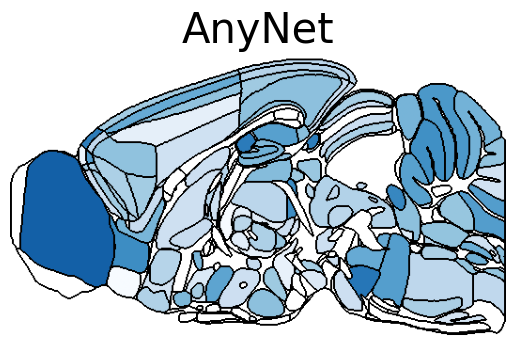

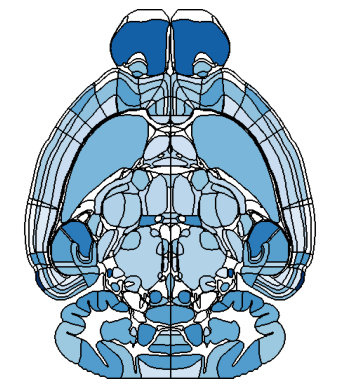

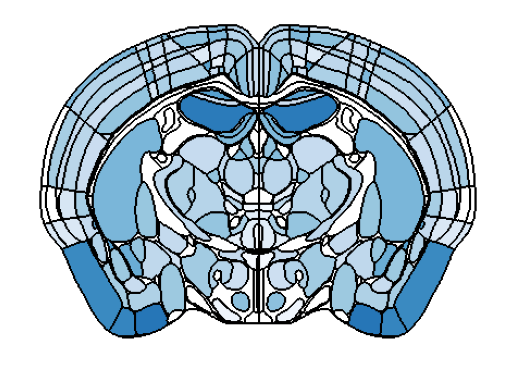

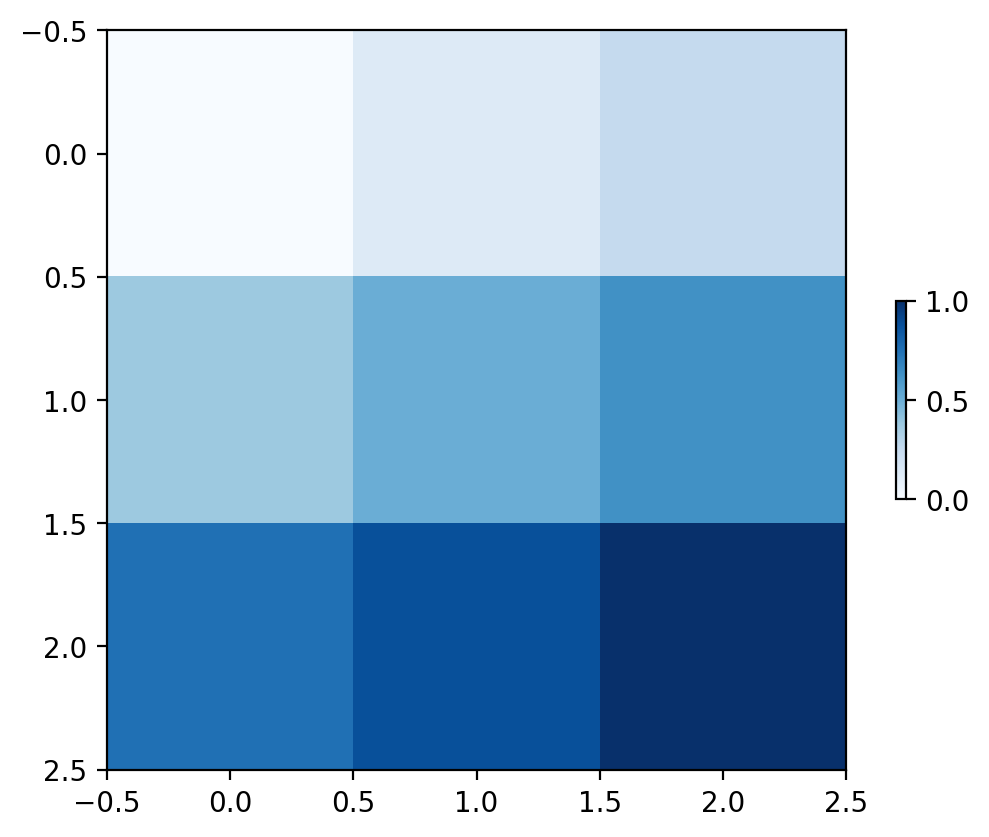

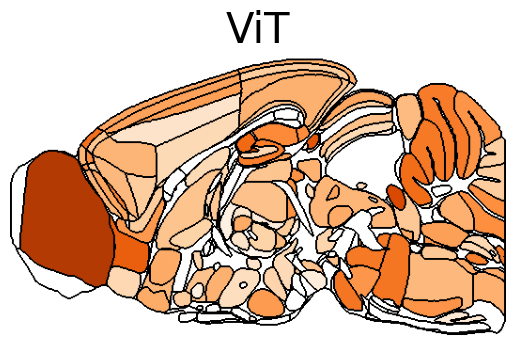

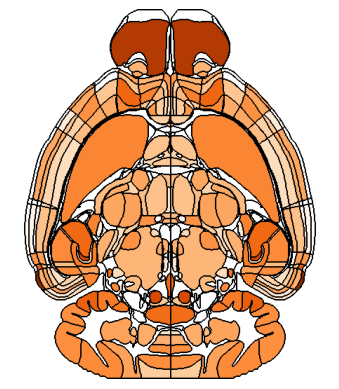

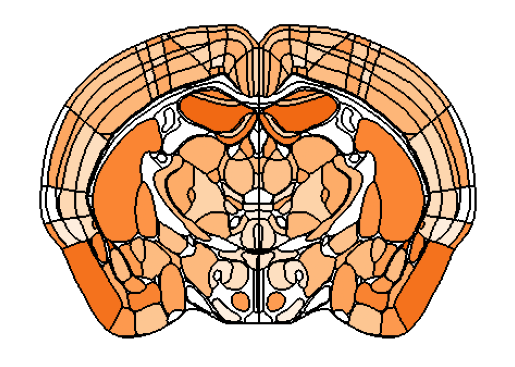

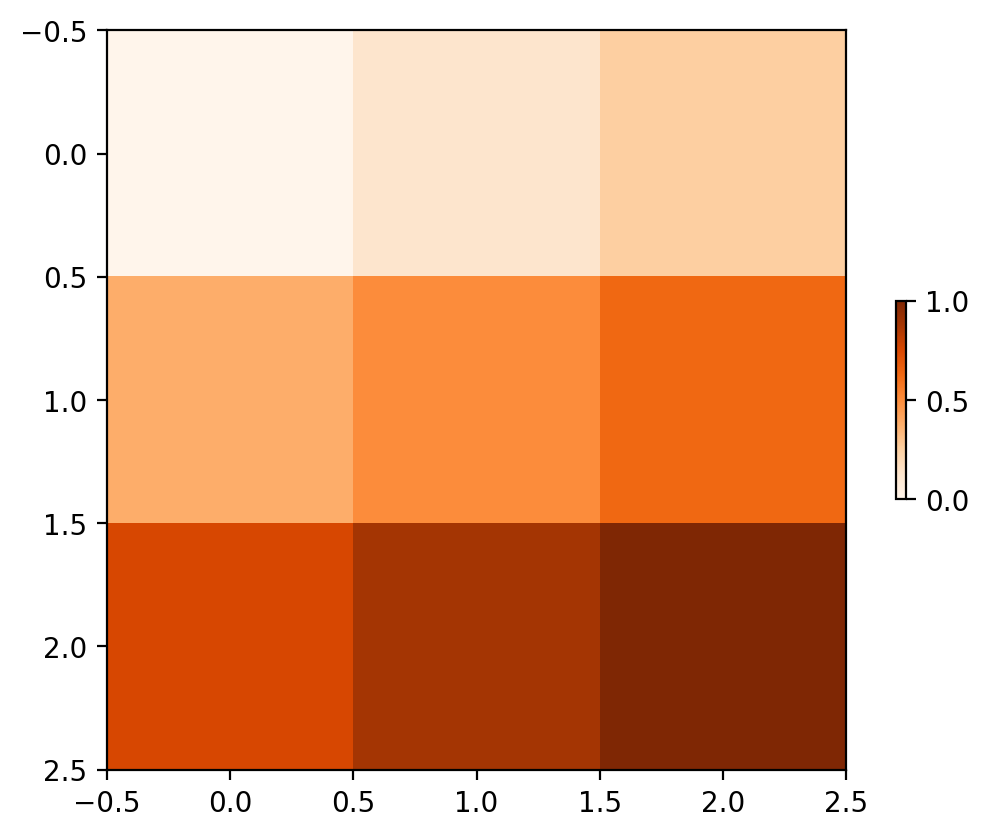

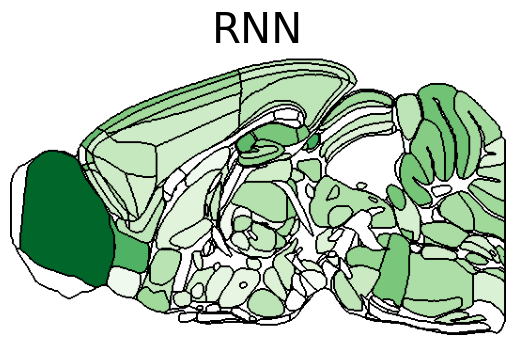

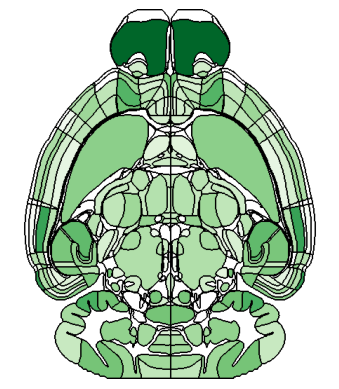

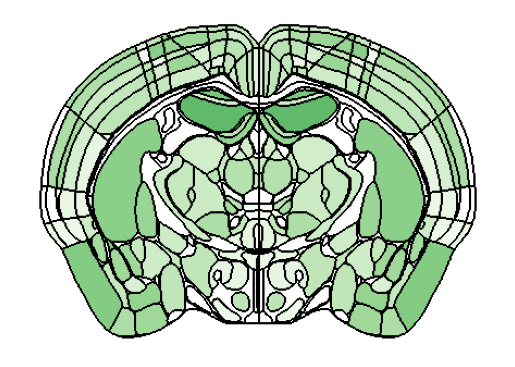

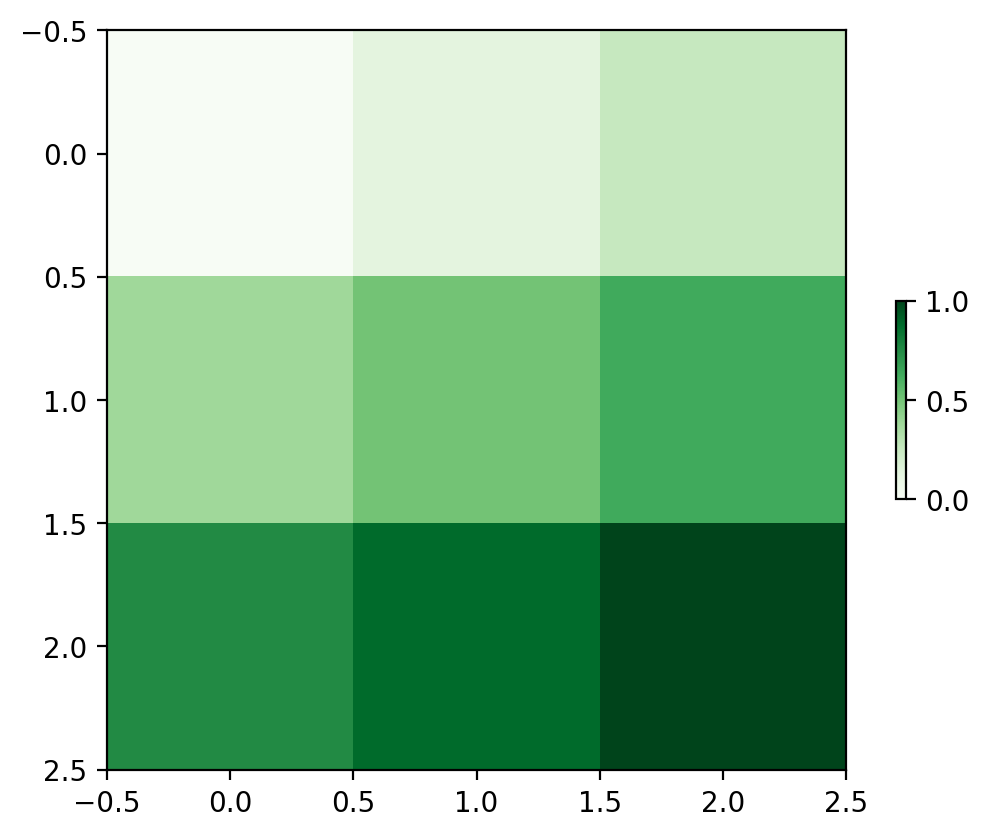

In [18]:
for Classifier_ii in range(0, 3):
    acronym_label = []
    acu_mean_list = []
    name0 = Classifier_name[Classifier_ii]
    color_map0 = color_map_list[Classifier_ii]
    for acronym_ii, acronym in enumerate(acronym_list):
        acu_test_dict_selec = acu_test_dict[acu_test_dict['acronym_test'] == acronym]
        if len(acu_test_dict_selec) < 1:
            continue

        mean0 = acu_test_dict_selec[acu_test_dict_selec['name'] == name0]['acu_test'].mean()
        acronym_label.append(acronym)
        acu_mean_list.append(mean0)

    for indice in range(-500, 0, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')
        plt.title(name0, fontsize=30)

    for indice in range(-3500, -3000, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')

    for indice in range(-1000, -500, 500):
        fig, ax = plot_scalar_on_slice(np.array(acronym_label), np.array(acu_mean_list), coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
                                    background='boundary', cmap=color_map0, brain_atlas=ba)
        plt.axis('off')

    plt.figure(dpi=200)
    plt.imshow(np.linspace(0, 1, 9).reshape(3, 3), color_map0)
    plt.colorbar(fraction=0.01)
    plt.show()

In [19]:
acu_overall = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/acu_overall.pt', weights_only=False)

In [20]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

In [21]:
def barplot_annotate_brackets_vertical(num1, num2, data, center, height, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    x = max(lx, rx) + dh
    barx = [x, x + barh, x + barh, x]
    bary = [ly, ly, ry, ry]

    mid = (x + 0.1, (ly + ry) / 2)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs, rotation='vertical')


In [22]:
# ['Chance', 'Linear', 'AnyNet', 'ViT', 'RNN']

_, p_cl = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'Chance']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'Linear']['acu_test_overall']), equal_var=False)

_, p_la = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'Linear']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'AnyNet']['acu_test_overall']), equal_var=False)

_, p_av = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'AnyNet']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'ViT']['acu_test_overall']), equal_var=False)

_, p_vr = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'ViT']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'RNN']['acu_test_overall']), equal_var=False)

_, p_lv = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'Linear']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'ViT']['acu_test_overall']), equal_var=False)

_, p_lr = sp.stats.ttest_ind(np.array(acu_overall[acu_overall['model_type'] == 'Linear']['acu_test_overall']),
                   np.array(acu_overall[acu_overall['model_type'] == 'RNN']['acu_test_overall']), equal_var=False)

In [ ]:
np.array(acu_overall[acu_overall['model_type'] == 'Linear']['acu_test_overall'])

In [23]:
for model in ['Linear', 'AnyNet', 'ViT', 'RNN']:
    print(model)
    print(np.array(acu_overall[acu_overall['model_type'] == model]['acu_test_overall']).mean())

Linear
0.12005627
AnyNet
0.3680426
ViT
0.38892695
RNN
0.31210294


/tmp/ipython-input-2832935240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipython-input-2832935240.py:4: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


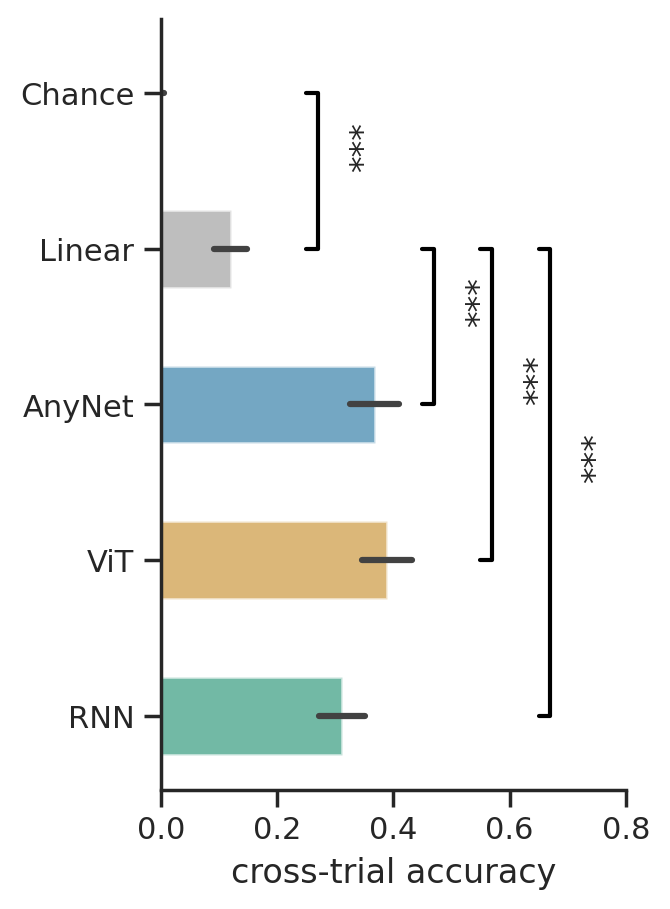

In [24]:
sns.set_theme(style='ticks')

plt.figure(figsize=(3, 5), dpi=200)
g = sns.barplot(
    data=acu_overall,
    x='acu_test_overall', y='model_type',
    errorbar='sd', width=0.5, palette=color_list_define, alpha=.6
)
barplot_annotate_brackets_vertical(0, 1, p_cl, center=np.array([0.15, 0.15]), height=np.array([0, 1]), dh=0.10, barh=.02, maxasterix=3)
barplot_annotate_brackets_vertical(0, 1, p_la, center=np.array([0.35, 0.35]), height=np.array([1, 2]), dh=0.10, barh=.02, maxasterix=3)

barplot_annotate_brackets_vertical(0, 1, p_lv, center=np.array([0.45, 0.45]), height=np.array([1, 3]), dh=0.10, barh=.02, maxasterix=3)
barplot_annotate_brackets_vertical(0, 1, p_lr, center=np.array([0.55, 0.55]), height=np.array([1, 4]), dh=0.10, barh=.02, maxasterix=3)

# barplot_annotate_brackets_vertical(0, 1, p_av, center=np.array([0.65, 0.65]), height=np.array([2, 2.95]), dh=0.10, barh=.02, maxasterix=3)
# barplot_annotate_brackets_vertical(0, 1, p_vr, center=np.array([0.65, 0.65]), height=np.array([3.05, 4]), dh=0.10, barh=.02, maxasterix=3)

plt.xlim([0, 0.8])
plt.ylabel('')
plt.xlabel('cross-trial accuracy')
sns.despine()
plt.show()
# plt.title(key)

In [25]:
factors_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/factors_dict.pt', weights_only=False)

In [26]:
from sklearn.linear_model import LinearRegression

In [ ]:
np.random.randint(0, 100, rep)

In [ ]:
len(factors_dict[Classifier_name[Classifier_ii]]['y'])

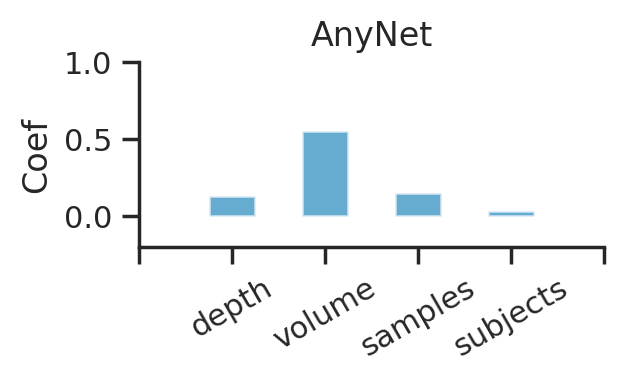

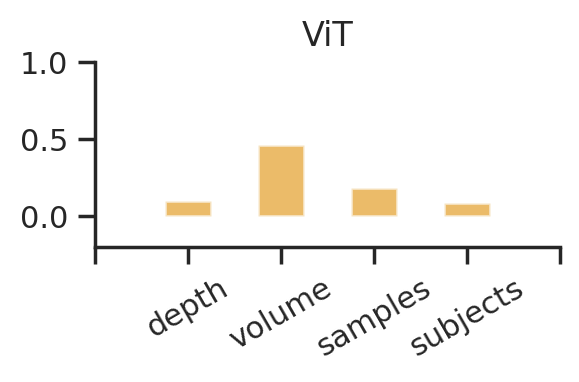

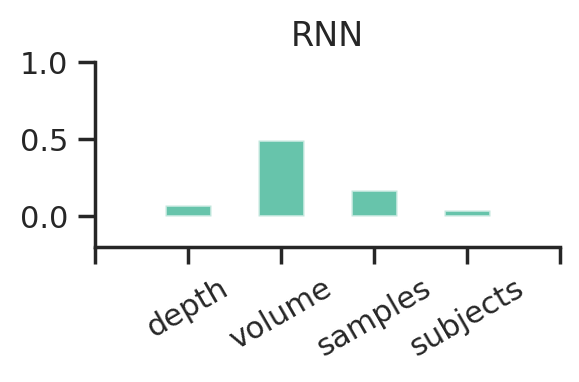

In [27]:
coef_factor = []
coef_value = []
coef_name = []
Classifier_name = ['AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate(Classifier_name):

    reg = LinearRegression().fit(factors_dict[Classifier_name[Classifier_ii]]['X0'][:, 0 : 4], factors_dict[Classifier_name[Classifier_ii]]['y'])

    for factor_ii, factor in enumerate(['depth', 'volume', 'samples', 'subjects']):
        coef_factor.append(factor)
        coef_value.append(reg.coef_[factor_ii])
        coef_name.append(Classifier_name[Classifier_ii])

    plt.figure(figsize=(3, 1.2), dpi=200)
    plt.bar([1, 2, 3, 4], reg.coef_, width=0.5, alpha=0.6, color=color_list[Classifier_ii])
    plt.xticks([0, 1, 2, 3, 4, 5], ['', 'depth', 'volume', 'samples', 'subjects', ''], rotation=30)
    if Classifier_ii == 0:
        plt.ylabel('Coef')
    plt.ylim([-0.2, 1.0])
    plt.title(f'{Classifier_name[Classifier_ii]}')
    sns.despine()

coef = pd.DataFrame({
    'Coef': np.array(coef_value),
    'Factor': coef_factor,
    'Name': coef_name,
})

In [28]:
from sklearn.metrics import r2_score

In [29]:
coef_factor = []
coef_value = []
coef_name = []
R2 = []
for repeat in range(0, 100):
    for Classifier_ii, Classifier in enumerate(Classifier_name):

        selec_index = np.unique(np.random.randint(0, len(factors_dict[Classifier_name[Classifier_ii]]['y']), 400))

        reg = LinearRegression().fit(factors_dict[Classifier_name[Classifier_ii]]['X0'][selec_index, 0 : 4], factors_dict[Classifier_name[Classifier_ii]]['y'][selec_index])
        r2 = reg.score(factors_dict[Classifier_name[Classifier_ii]]['X0'][selec_index, 0 : 4], factors_dict[Classifier_name[Classifier_ii]]['y'][selec_index])
        R2.append(r2)

        for factor_ii, factor in enumerate(['depth', 'volume', 'samples', 'subjects']):
            coef_factor.append(factor)
            coef_value.append(reg.coef_[factor_ii])
            coef_name.append(Classifier_name[Classifier_ii])

coef = pd.DataFrame({
    'Coef': np.array(coef_value),
    'Factor': coef_factor,
    'Name': coef_name,
})

In [30]:
np.array(R2).mean()

np.float64(0.1419720495191976)

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
sns.set_theme(style='ticks')

plt.figure(figsize=(3, 5), dpi=200)
g = sns.barplot(
    data=coef,
    x='Coef', y='Factor', hue='Name',
    palette=color_list, alpha=.6
)
# plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Coef')
sns.despine()
sns.move_legend(g, loc='lower right', title=None)
plt.show()
# plt.title(key)

In [31]:
acu_subject = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/acu_subject.pt', weights_only=False)

In [ ]:
sns.set_theme(style="whitegrid")

sns.set_theme(rc={'figure.dpi': 200, 'figure.figsize': (3, 1)}, style='whitegrid')
g = sns.catplot(
    data=acu_subject, kind='bar',
    x='acu_test_subject', y='acronym_subject_test', col='model_type',
    errorbar='sd', palette='colorblind', height=8.0, aspect=0.3,
)
g.set(xlim=[0, 1.0])
g.set(xticks=[0, 0.25, 0.50, 0.75, 1.0])
g.set(xticklabels=['0', '0.25', '0.50', '0.75', '1.0'])
g.set(ylabel='')
g.set(xlabel='')
for item, ax in g.axes_dict.items():
    g.set_titles('')

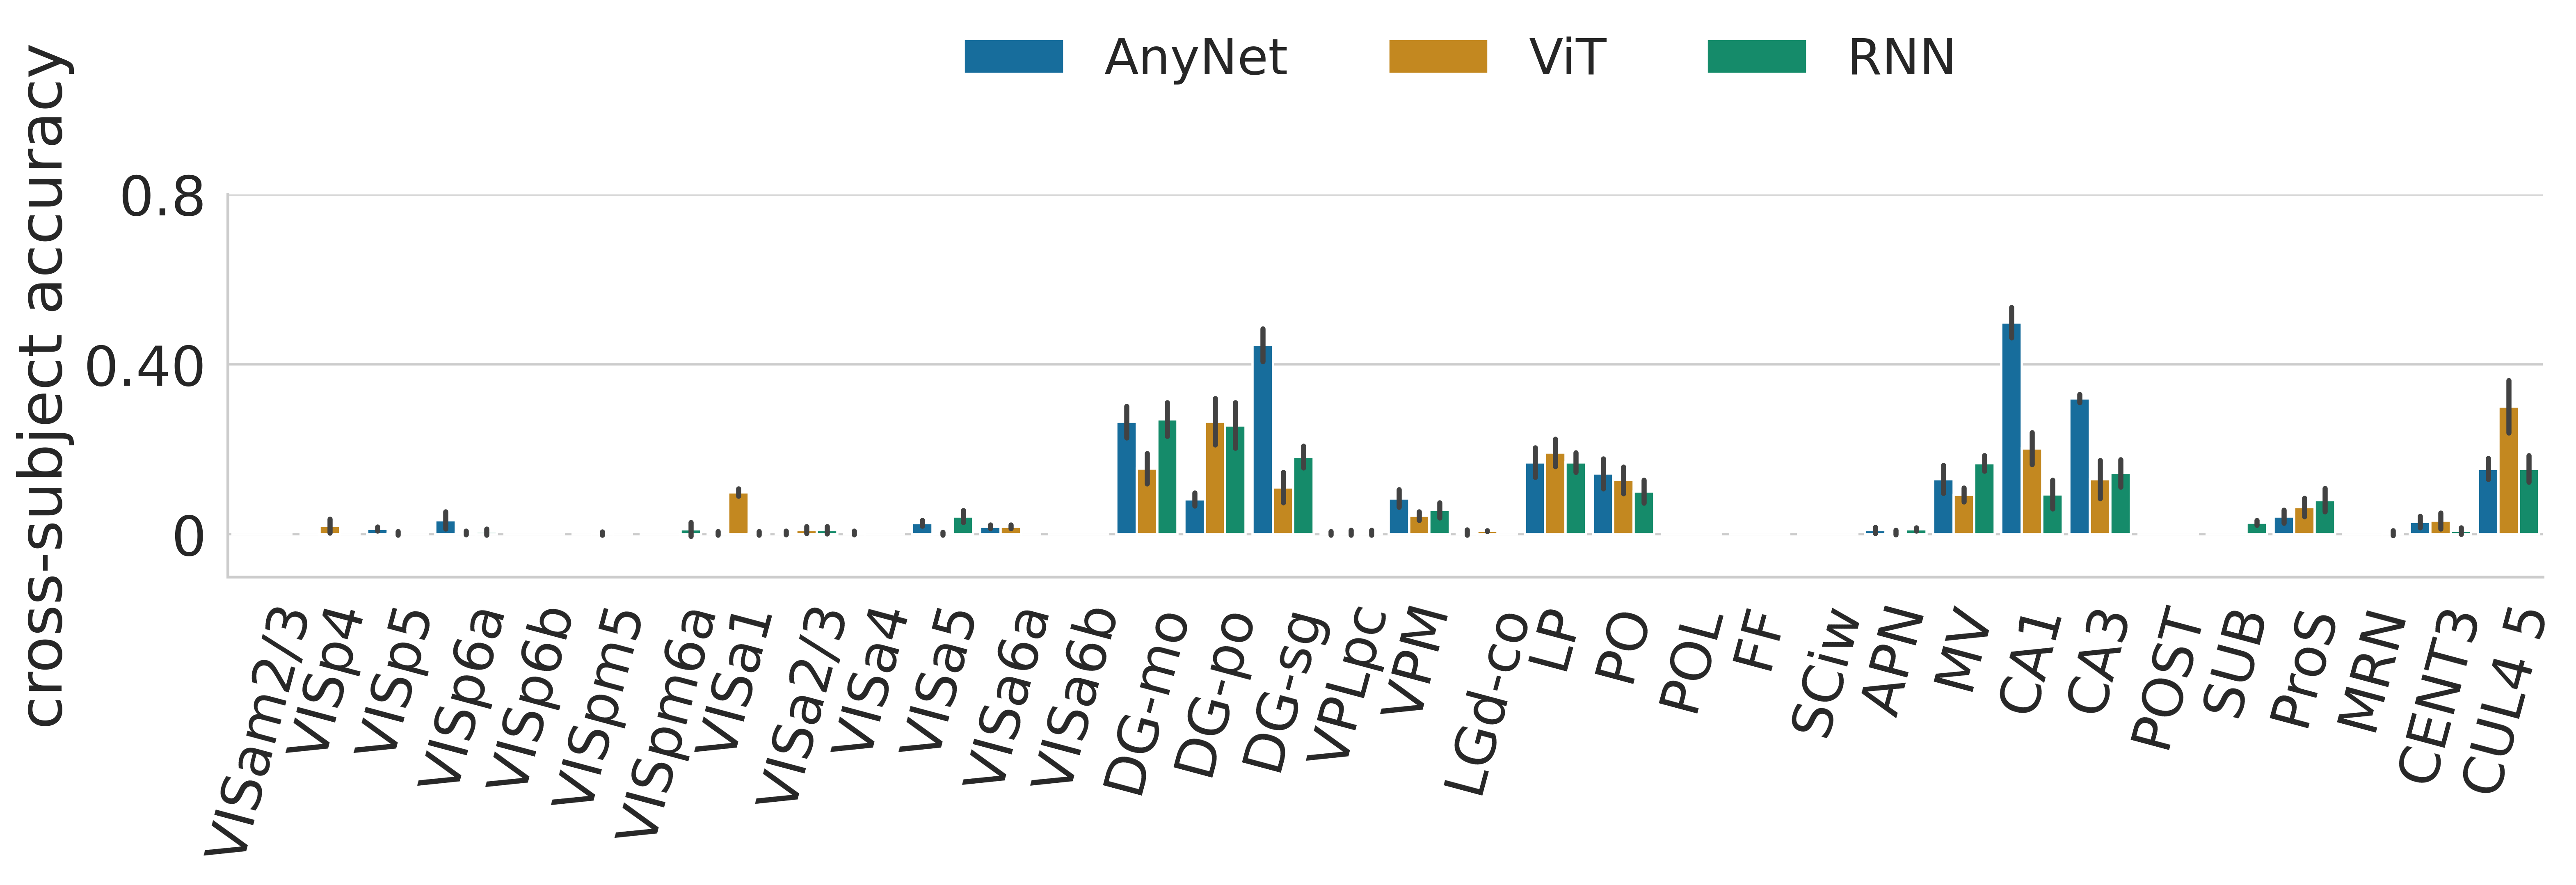

In [32]:
sns.set_theme(rc={'figure.dpi': 400,}, style='whitegrid', font_scale=2.2)
g = sns.catplot(
    data=acu_subject, kind='bar',
    x='acronym_subject_test', y='acu_test_subject', hue='model_type',
    errorbar='sd', palette='colorblind', width=0.9, height=4.0, aspect=4.0,
)
g.set(ylim=[-0.1, 0.8])
g.set(yticks=[0, 0.4, 0.8])
g.set(yticklabels=['0', '0.40', '0.8'])
# g.set_xticklabels(fontsize=12)
g.set(ylabel='')
g.set(xlabel='')
plt.xticks(rotation=75)
g.set(ylabel='cross-subject accuracy')
for item, ax in g.axes_dict.items():
    g.set_titles('')
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=22)
# g._legend.remove()

In [ ]:
sns.set_theme(rc={'figure.dpi': 400, 'figure.figsize': (5, 1)}, style='whitegrid', font_scale=2)
g = sns.catplot(
    data=acu_subject, kind='bar',
    x='acronym_subject_test', y='acu_test_subject', row='model_type',
    errorbar='sd', palette='colorblind', height=2.0, aspect=8.0,
)
g.set(ylim=[-0.1, 1.0])
g.set(yticks=[0, 0.50, 1.0])
g.set(yticklabels=['0', '0.50', '1.0'])
# g.set_xticklabels(fontsize=12)
g.set(ylabel='')
g.set(xlabel='')
plt.xticks(rotation=60)
# g.set(ylabel='')
for item, ax in g.axes_dict.items():
    g.set_titles('')

In [33]:
accu_in_out_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu1/accu_in_out_dict.pt', weights_only=False)

In [34]:
in_out_stat = {}
for model in Classifier_name:
    in_out_stat[model] = sp.stats.pearsonr(accu_in_out_dict[accu_in_out_dict['model'] == model]['accu_in'], accu_in_out_dict[accu_in_out_dict['model'] == 'AnyNet']['accu_out'])


<Figure size 1000x1000 with 0 Axes>

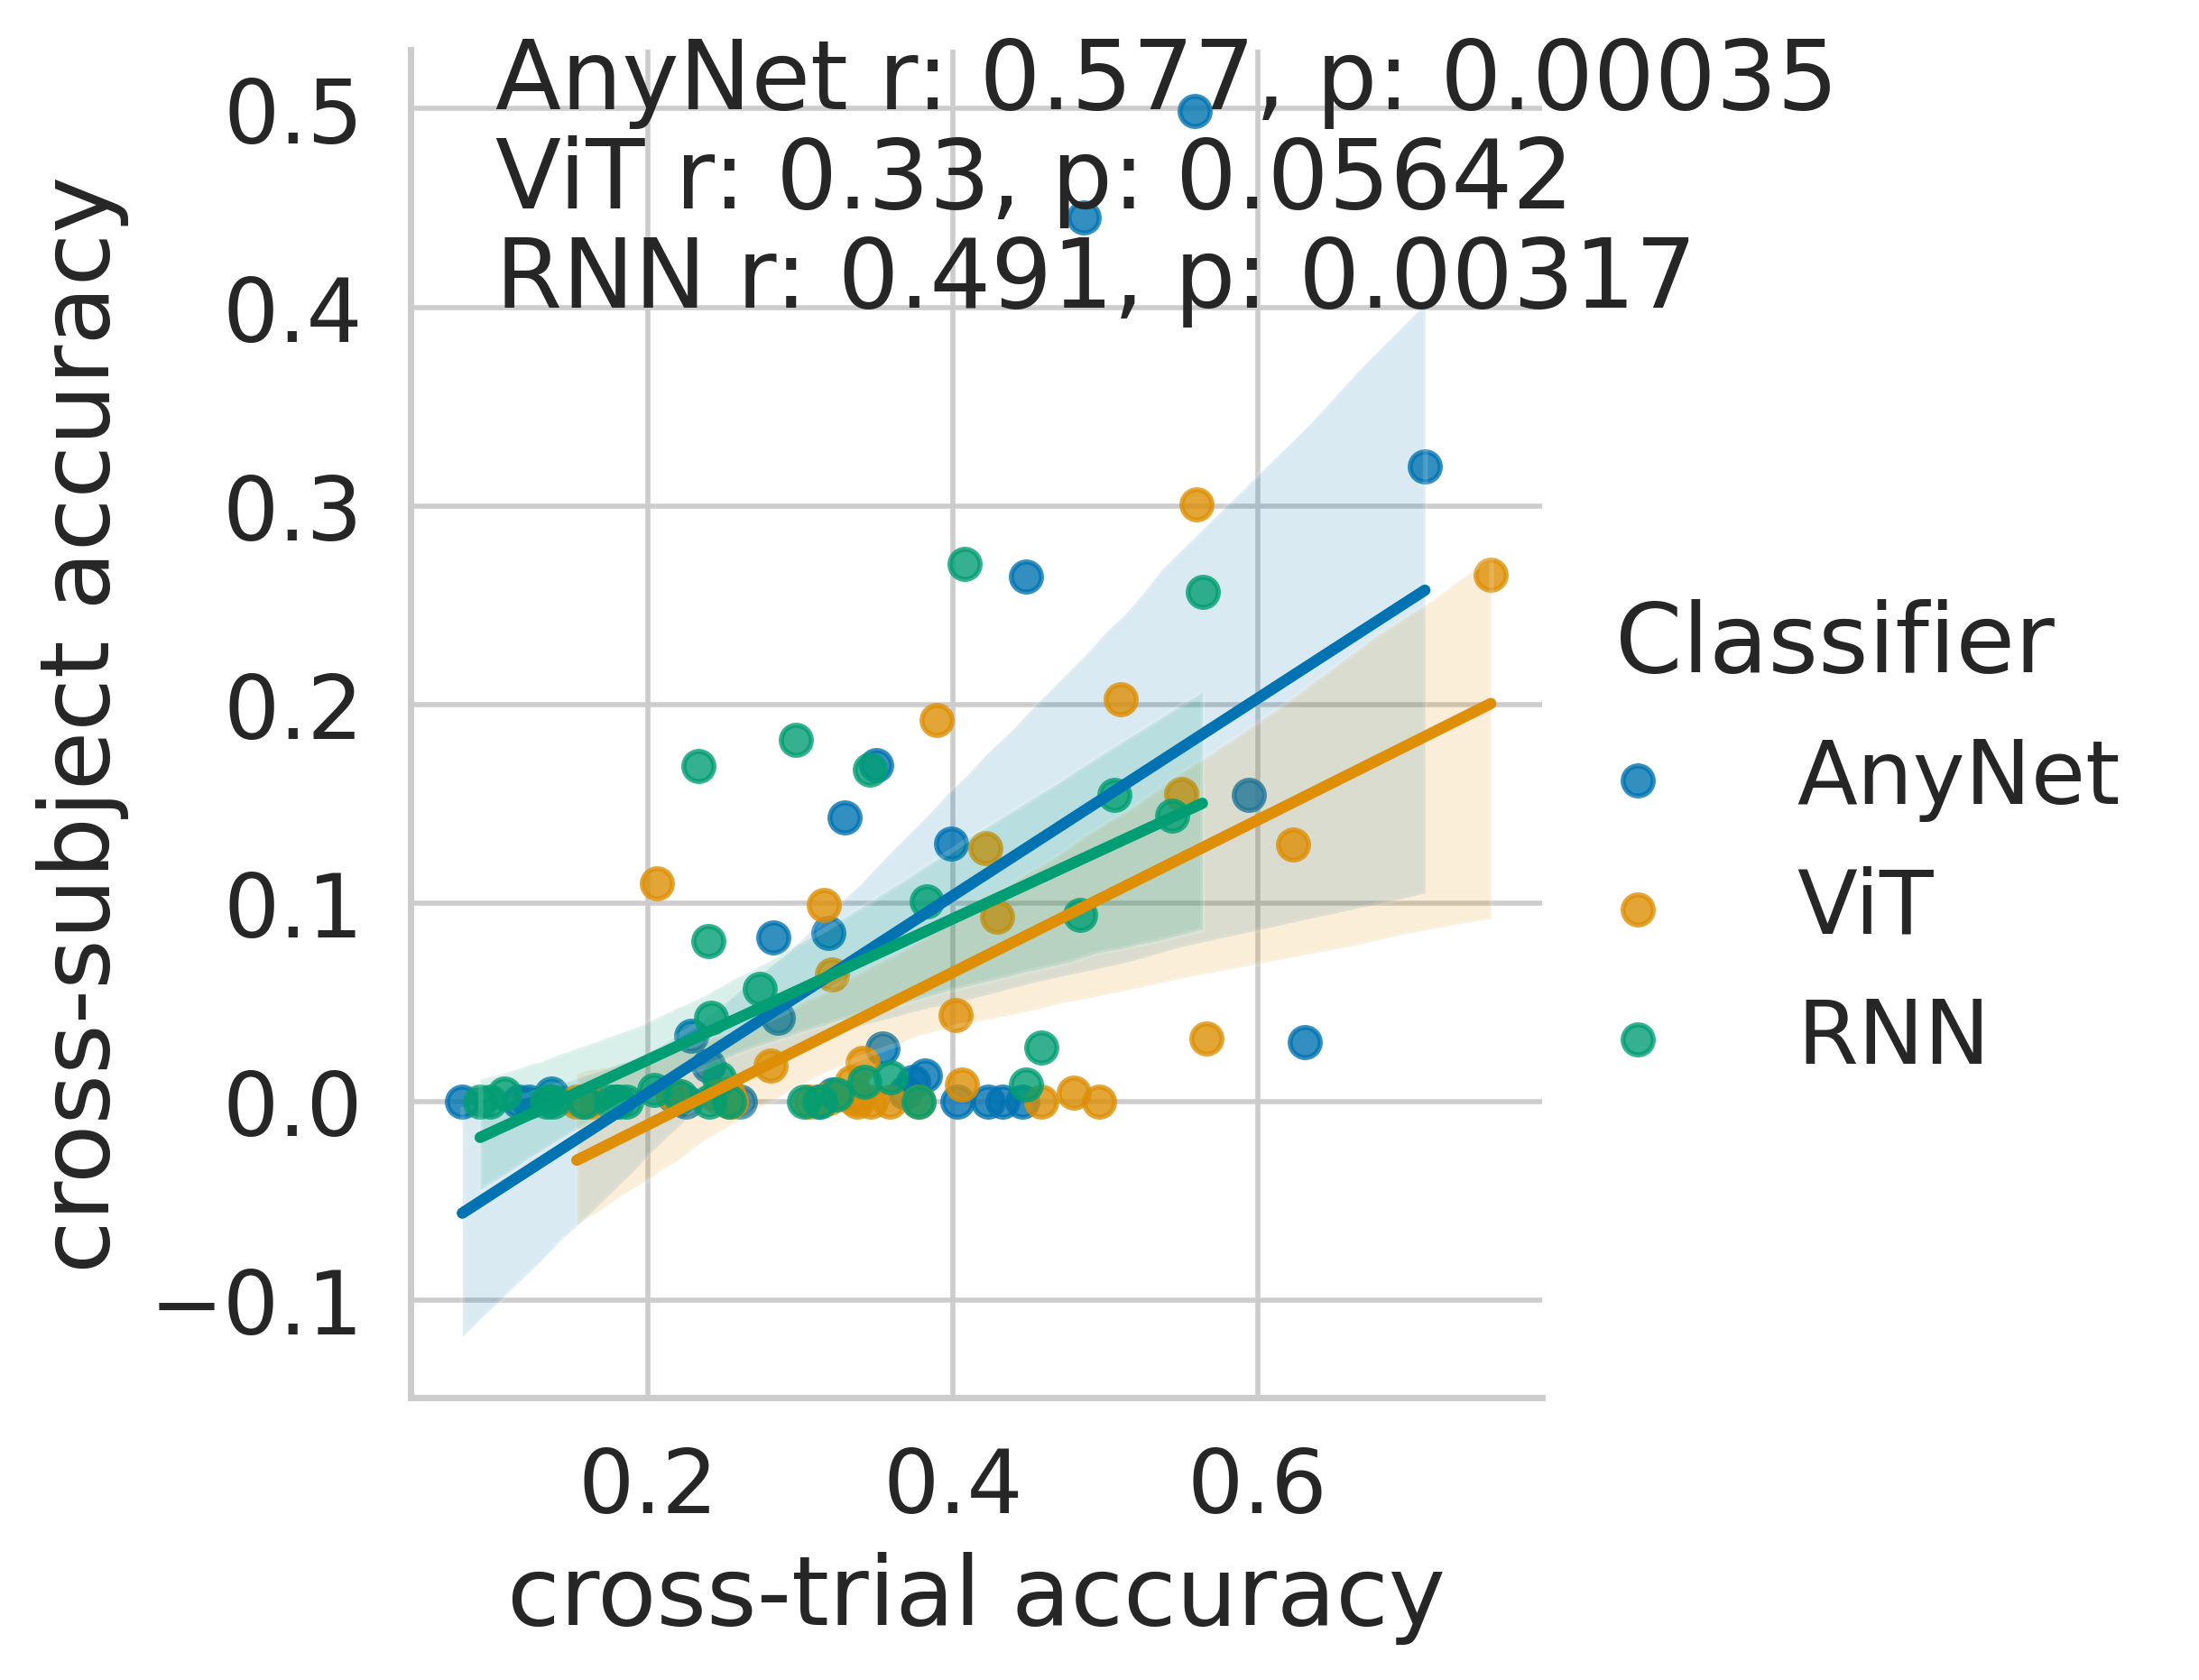

In [35]:
sns.set_theme(rc={'figure.dpi': 400, 'figure.figsize': (5, 5)}, style='whitegrid', font_scale=1.6)
plt.figure(figsize=(5, 5), dpi=200)
g = sns.lmplot(data=accu_in_out_dict, x='accu_in', y='accu_out', hue='model', palette='colorblind')
g.set(ylabel='')
g.set(xlabel='')
plt.xlabel('cross-trial accuracy')
plt.ylabel('cross-subject accuracy')
g.legend.set_title('Classifier')
for model_ii, model in enumerate(Classifier_name):
    plt.text(0.1, 0.5 - 0.05 * model_ii, f'{model} r: {np.round(in_out_stat[model][0], 3)}, p: {np.round(in_out_stat[model][1], 5)}')
plt.show()

In [ ]:
sns.set_theme(rc={'figure.dpi': 400, 'figure.figsize': (5, 5)}, style='whitegrid', font_scale=1.6)
plt.figure(figsize=(5, 5), dpi=200)
g = sns.lmplot(data=accu_in_out_dict, x='accu_in', y='accu_out', hue='model', palette='colorblind')
g.set(ylabel='')
g.set(xlabel='')
plt.xlabel('cross-trial accuracy')
plt.ylabel('cross-subject accuracy')
g.legend.set_title('Classifier')
# for model_ii, model in enumerate(Classifier_name):
#     plt.text(0.1, 0.5 - 0.05 * model_ii, f'{model} r: {np.round(in_out_stat[model][0], 3)}, p: {np.round(in_out_stat[model][1], 5)}')
plt.show()

In [ ]:
plt.figure(figsize=(5, 5), dpi=200)
g = sns.lmplot(data=accu_in_out_dict, x='accu_in', y='accu_out', hue='model', palette='colorblind')
g.set(ylabel='')
g.set(xlabel='')
plt.xlabel('cross-trial accuracy')
plt.ylabel('cross-subject accuracy')
# for model_ii, model in enumerate(Classifier_name):
#     plt.text(0.1, 0.5 - 0.05 * model_ii, f'{model} r: {np.round(in_out_stat[model][0], 3)}, p: {np.round(in_out_stat[model][1], 5)}')
g.legend.set_title('Classifier')
plt.show()

In [ ]:
accu_in_out_dict[accu_in_out_dict['model'] == 'AnyNet']

In [ ]:
from google.colab import runtime
runtime.unassign()